In [8]:
!pip install torch==2.5.0+cu124 torchvision==0.20.0+cu124 torchaudio==2.5.0 \
    --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 3.3 MB/s eta 0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 95.6 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127

In [3]:
!pip list

Package                                  Version
---------------------------------------- -------------------
a2a-sdk                                  0.3.25
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiobotocore                              3.3.0
aiofiles                                 22.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aioitertools                             0.13.0
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc               

In [1]:
!nvidia-smi

Mon Apr 27 14:17:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


# 1. IMPORTING PERTINENT LIBRARIES

In [15]:
import os
import tqdm
import random

import matplotlib.pyplot as plt
import numpy as np

import cv2

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
%matplotlib inline 

In [16]:
path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"
yes_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes"
no_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no"

/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes
Total Images for YES is: 155
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no
Total Images for NO is: 98


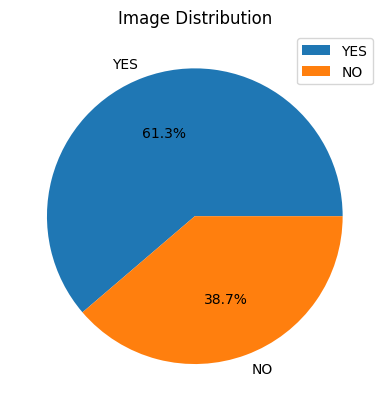

In [17]:
yes_counts = 0
no_counts = 0

# Count images in YES path
for dirpath, dirnames, filenames in os.walk(yes_path):
    print(dirpath)
    print(f"Total Images for YES is: {len(filenames)}")
    yes_counts += len(filenames)

# Count images in NO path
for dirpath, dirnames, filenames in os.walk(no_path):
    print(dirpath)
    print(f"Total Images for NO is: {len(filenames)}")
    no_counts += len(filenames)

# Plot pie chart
plt.pie([yes_counts, no_counts], labels=["YES", "NO"], autopct="%1.1f%%")
plt.title("Image Distribution")
plt.legend()
plt.show()

## 1.1 SETTING CONSTANTS AND PARAMETERS

In [18]:
random_seed = 28
epoch = 0
batch_size = 32
sample_size = 10

# GENERATING SAMPLE IMAGES (ORIGINAL)

In [19]:
def load_samples(base_path, num_samples):
    yes_data = []
    no_data = []

    for cls in ["yes", "no"]:
        folder = os.path.join(base_path, cls)
        images = [img for img in os.listdir(folder) if img.lower().endswith((".png", ".jpg", ".jpeg"))]

        sampled = random.sample(images, min(num_samples, len(images)))

        for img_name in sampled:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if cls == "yes":
                yes_data.append(img)
            else:
                no_data.append(img)

    return yes_data, no_data

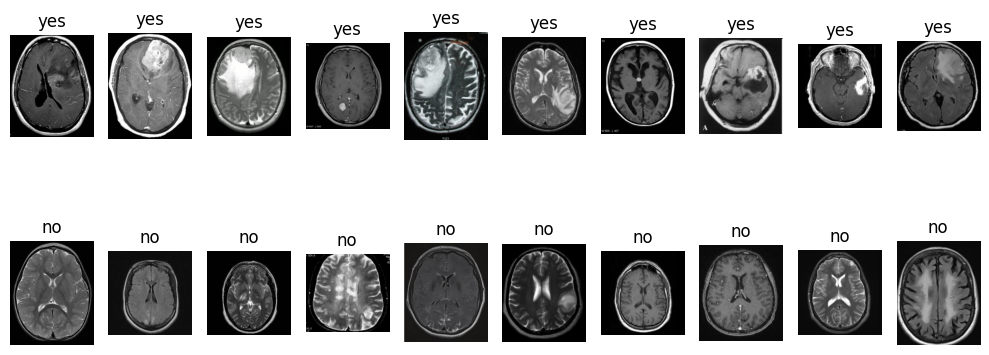

In [20]:
def show_samples(samples):

    plt.figure(figsize=(10, 5))

    for i, (img, label) in enumerate(samples):
        plt.subplot(2, len(samples)//2, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

yes_data, no_data = load_samples(path, sample_size)
samples = [(img, "yes") for img in yes_data] + \
          [(img, "no") for img in no_data]

show_samples(samples)

#  **PYTORCH DEEP LEARNING**

# TORCH DATA LOADER

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import torch.nn.functional as F

# Torchvision
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B4_Weights, ResNet50_Weights

In [53]:
# Root path that contains ONLY "yes" and "no" folders
path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load dataset once, pointing to the root folder
dataset = datasets.ImageFolder(root=path, transform=transform)

# Check mapping
print(dataset.class_to_idx)

# Create DataLoader
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Example: get one batch
images, labels = next(iter(loader))
print(images.shape)   
print(labels)

{'no': 0, 'yes': 1}
torch.Size([32, 3, 128, 128])
tensor([1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
        0, 1, 0, 0, 1, 1, 1, 0])


# TORCH RANDOM UPSAMPLING

In [54]:
# Targets
targets = torch.tensor(dataset.targets)

print("Before WRS:", Counter(targets.tolist()))

# Class balancing
class_counts = torch.bincount(targets)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(dataset),
    replacement=True
)

loader = DataLoader(dataset, batch_size=32, sampler=sampler)

sampled_counter = Counter()

for _, batch_labels in loader:
    sampled_counter.update(batch_labels.tolist())

print("After WRS:", sampled_counter)

# One batch check
images, batch_labels = next(iter(loader))
print("One batch distribution:", Counter(batch_labels.tolist()))
print("Batch shape:", images.shape)

Before WRS: Counter({1: 155, 0: 98})
After WRS: Counter({1: 138, 0: 115})
One batch distribution: Counter({0: 18, 1: 14})
Batch shape: torch.Size([32, 3, 128, 128])


In [55]:
targets = dataset.targets

train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    stratify=targets,
    random_state=random_seed
)

train_targets = [targets[i] for i in train_idx]
train_targets = torch.tensor(train_targets)

class_counts = torch.bincount(train_targets)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[train_targets]

# Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_targets),
    replacement=True
)

# Applying Transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [58]:
train_dataset = Subset(
    datasets.ImageFolder(root=path, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(root=path, transform=val_transform),
    val_idx
)

# DATA LOADER

In [60]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# SIMPLE CNN MODEL

In [62]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Feature extractor ---
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 128 → 64
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 → 32
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 → 16
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 16 → 8
        )

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # binary output
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.classifier(x)
        return x

# RESNET50 CNN MODEL

In [33]:
class BrainTumorResNet50(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained ResNet50
        self.backbone = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last block (layer4)
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Replace classifier (fc layer)
        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # binary classification
        )

    def forward(self, x):
        return self.backbone(x)

# EFFICIENTNETB4 CNN MODEL

In [34]:
class BrainTumorEffNetB4(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained EfficientNet-B4
        self.backbone = models.efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        # Freeze all layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last few layers (classifier block equivalent)
        for param in self.backbone.features[-1].parameters():
            param.requires_grad = True

        # Replace classifier
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # binary output
        )

    def forward(self, x):
        return self.backbone(x)

In [35]:
model0 = SimpleCNN()
model1 = BrainTumorResNet50()
model2 = BrainTumorEffNetB4()

def model_description(model, original_model=None):
    # Count total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if original_model is not None:
        original_params = sum(p.numel() for p in original_model.parameters())
        percent = (total_params / original_params) * 100
        print(f"Total parameters: {total_params} ({percent:.2f}% of baseline)")
    else:
        print(f"Total parameters: {total_params}")

    print(f"Trainable parameters: {trainable_params}")

print("Simple CNN Parameters:")
model_description(model0)
print("\n")
print("Resnet50 CNN Parameters:")
model_description(model1, model0)
print("\n")
print("EfficientNetB4 CNN Parameters:")
model_description(model2, model0)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 226MB/s]


Simple CNN Parameters:
Total parameters: 1147009
Trainable parameters: 1147009


Resnet50 CNN Parameters:
Total parameters: 24033345 (2095.31% of baseline)
Trainable parameters: 15490049


EfficientNetB4 CNN Parameters:
Total parameters: 18008393 (1570.03% of baseline)
Trainable parameters: 1266177


# EALY STOPPING CLASS

In [36]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best
        
        self.best_loss = float("inf")
        self.counter = 0
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best:
                self.best_model = model.state_dict()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print("Early stopping triggered")
            if self.restore_best and self.best_model:
                model.load_state_dict(self.best_model)
            return True

        return False

# SIMPLE CNN TORCHTRAINER

In [50]:
class TorchTrainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        patience=7,
        epochs=epoch
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device

        # Early stopping
        self.patience = patience
        self.best_val_loss = float("inf")
        self.counter = 0
        self.best_weights = None

        # Logs
        self.history = defaultdict(list)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0

        for images, labels in self.train_loader:
            images = images.to(self.device)
            labels = labels.float().unsqueeze(1).to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                labels = labels.float().unsqueeze(1).to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()

        return total_loss / len(self.val_loader)

    def fit(self, epochs=epoch):
        for epoch in range(epochs):
            train_loss = self.train_one_epoch()
            val_loss = self.validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)

            print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

            # Early stopping logic
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.counter = 0
                self.best_weights = self.model.state_dict()
            else:
                self.counter += 1

            if self.counter >= self.patience:
                print("Early stopping triggered")
                self.model.load_state_dict(self.best_weights)
                break

        return self.history

In [64]:
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCEWithLogitsLoss()

trainer = TorchTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    patience=7
)

history0 = trainer.fit(epochs=30)
print(history0)

print("History keys:", history0.keys())
print("Train loss len:", len(history0.get("train_loss", [])))
print("Val loss len:", len(history0.get("val_loss", [])))

Epoch 1: train=0.4813, val=0.6651
Epoch 2: train=0.5630, val=0.6874
Epoch 3: train=0.4008, val=0.6122
Epoch 4: train=0.3700, val=0.5608
Epoch 5: train=0.3132, val=0.4727
Epoch 6: train=0.3023, val=0.4001
Epoch 7: train=0.2230, val=0.3352
Epoch 8: train=0.3102, val=0.4129
Epoch 9: train=0.2875, val=0.3574
Epoch 10: train=0.2275, val=0.3864
Epoch 11: train=0.2204, val=0.3018
Epoch 12: train=0.2202, val=0.3788
Epoch 13: train=0.2327, val=0.4045
Epoch 14: train=0.1558, val=0.4246
Epoch 15: train=0.1767, val=0.3956
Epoch 16: train=0.1196, val=0.3932
Epoch 17: train=0.1658, val=0.3378
Epoch 18: train=0.1511, val=0.4119
Early stopping triggered
defaultdict(<class 'list'>, {'train_loss': [0.48131783519472393, 0.5630036209310804, 0.40080095188958303, 0.36999652641160147, 0.3131772790636335, 0.3023450268166406, 0.22304075743470872, 0.3102153220346996, 0.28749777589525494, 0.2275367272751672, 0.22039939250264848, 0.22017386981419154, 0.23274639674595424, 0.15583821279661997, 0.17673040394272124, 

# MODEL PERFORMANCE

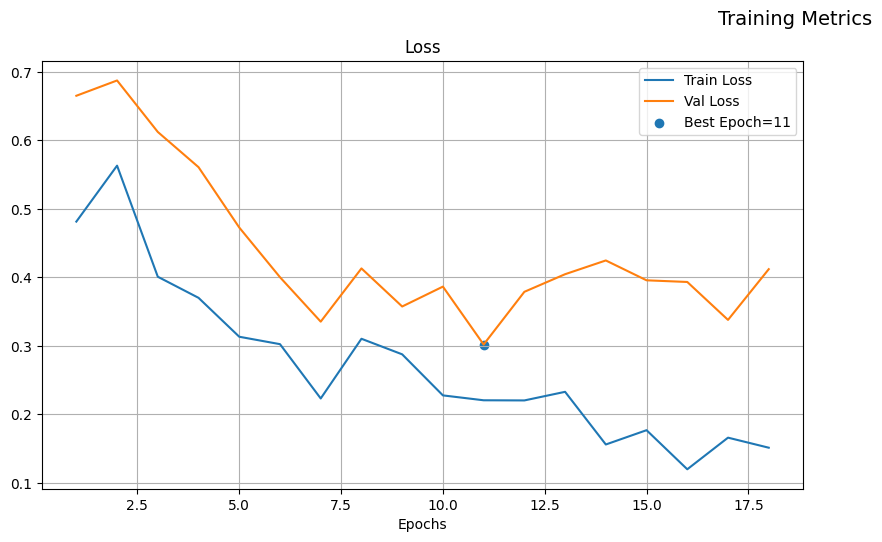

In [65]:
def plot_training_metrics(history):
    # Required
    tr_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])

    # Optional metrics (if you add them later)
    tr_acc = history.get('train_acc', [])
    val_acc = history.get('val_acc', [])
    tr_per = history.get('train_precision', [])
    val_per = history.get('val_precision', [])
    tr_recall = history.get('train_recall', [])
    val_recall = history.get('val_recall', [])

    epochs = range(1, len(tr_loss) + 1)

    plt.figure(figsize=(16, 10))

    # ---- LOSS ----
    plt.subplot(2, 2, 1)
    plt.plot(epochs, tr_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')

    if val_loss:
        idx = np.argmin(val_loss)
        plt.scatter(idx+1, val_loss[idx], label=f'Best Epoch={idx+1}')

    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid()

    # ---- ACCURACY ----
    if tr_acc and val_acc:
        plt.subplot(2, 2, 2)
        plt.plot(epochs, tr_acc, label='Train Acc')
        plt.plot(epochs, val_acc, label='Val Acc')

        idx = np.argmax(val_acc)
        plt.scatter(idx+1, val_acc[idx], label=f'Best Epoch={idx+1}')

        plt.title('Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    # ---- PRECISION ----
    if tr_per and val_per:
        plt.subplot(2, 2, 3)
        plt.plot(epochs, tr_per, label='Train Precision')
        plt.plot(epochs, val_per, label='Val Precision')

        idx = np.argmax(val_per)
        plt.scatter(idx+1, val_per[idx], label=f'Best Epoch={idx+1}')

        plt.title('Precision')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    # ---- RECALL ----
    if tr_recall and val_recall:
        plt.subplot(2, 2, 4)
        plt.plot(epochs, tr_recall, label='Train Recall')
        plt.plot(epochs, val_recall, label='Val Recall')

        idx = np.argmax(val_recall)
        plt.scatter(idx+1, val_recall[idx], label=f'Best Epoch={idx+1}')

        plt.title('Recall')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    plt.suptitle("Training Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training_metrics(history0)

# EVALUATE MODEL

In [ ]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

# CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()